In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import plotly.express as px

In [2]:
# 1. Load Data
df = pd.read_csv('student_data_extended.csv')
df = df.drop(columns=['Unnamed: 0'])
print("Dataset Loaded. Shape:", df.shape)
df.head()

Dataset Loaded. Shape: (1000, 2)


,ExtracurricularActivities,ClubMemberships
0,Debate Club,"Music Club, Art Club, Sports Team, Debate Club..."
1,Debate Club,"Art Club, Music Club, Sports Team, Coding Club"
2,Volunteer Group,"Music Club, Art Club, Debate Club, Volunteer G..."
3,Volunteer Group,"Sports Team, Volunteer Group"
4,Sports Team,"Sports Team, Volunteer Group, Music Club"


In [3]:
# ClubMemberships already has the rich combo data — use it as the main feature
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].fillna('').str.lower().str.replace(',', ' ')
df['ClubMemberships'] = df['ClubMemberships'].fillna('').str.lower().str.replace(',', ' ')

# Weight ClubMemberships more (repeat it 3x so it dominates)
df['Combined_Info'] = df['ClubMemberships'] + ' ' + df['ClubMemberships'] + ' ' + df['ExtracurricularActivities']

In [4]:
df.head()

,ExtracurricularActivities,ClubMemberships,Combined_Info
0,debate club,music club art club sports team debate club...,music club art club sports team debate club...
1,debate club,art club music club sports team coding club,art club music club sports team coding club...
2,volunteer group,music club art club debate club volunteer g...,music club art club debate club volunteer g...
3,volunteer group,sports team volunteer group,sports team volunteer group sports team volu...
4,sports team,sports team volunteer group music club,sports team volunteer group music club sport...


In [5]:
df.shape

(1000, 3)

In [6]:
col1 = "ExtracurricularActivities"
col2 = "ClubMemberships"

# Unique counts
print("Unique ExtracurricularActivities:", df[col1].nunique())
print("Unique ClubMemberships:", df[col2].nunique())

Unique ExtracurricularActivities: 6
Unique ClubMemberships: 548


In [7]:
print("ExtracurricularActivities:\n", sorted(df[col1].dropna().unique()))
print("\nClubMemberships:\n", sorted(df[col2].dropna().unique()))

ExtracurricularActivities:
 ['art club', 'coding club', 'debate club', 'music club', 'sports team', 'volunteer group']

ClubMemberships:
 ['art club', 'art club  coding club', 'art club  coding club  debate club', 'art club  coding club  debate club  sports team', 'art club  coding club  music club  debate club  sports team', 'art club  coding club  music club  sports team  volunteer group', 'art club  coding club  music club  volunteer group  sports team', 'art club  coding club  music club  volunteer group  sports team  debate club', 'art club  coding club  sports team  music club  volunteer group', 'art club  coding club  sports team  volunteer group', 'art club  coding club  volunteer group', 'art club  coding club  volunteer group  debate club', 'art club  coding club  volunteer group  debate club  music club', 'art club  coding club  volunteer group  debate club  sports team', 'art club  coding club  volunteer group  debate club  sports team  music club', 'art club  coding club  

In [8]:
print(df.groupby(col1)[col2].nunique())

ExtracurricularActivities
art club           122
coding club        115
debate club        130
music club         145
sports team        128
volunteer group    131
Name: ClubMemberships, dtype: int64


In [9]:
df[[col1, col2]].nunique()

ExtracurricularActivities      6
ClubMemberships              548
dtype: int64

In [10]:
# ✅ REPLACE Cell 8 with:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),       # captures longer club name combos
    min_df=2,                 # ignore extremely rare combos
    max_df=0.95,              # ignore combos that appear in almost every student
    sublinear_tf=True         # dampens very frequent terms
)
X_binary = vectorizer.fit_transform(df['Combined_Info'])
print(f"Feature matrix: {X_binary.shape}")

Feature matrix: (1000, 86)


In [11]:
max_components = min(10, X_binary.shape[1] - 1)
svd = TruncatedSVD(n_components=max_components, random_state=42)
X_svd = svd.fit_transform(X_binary)

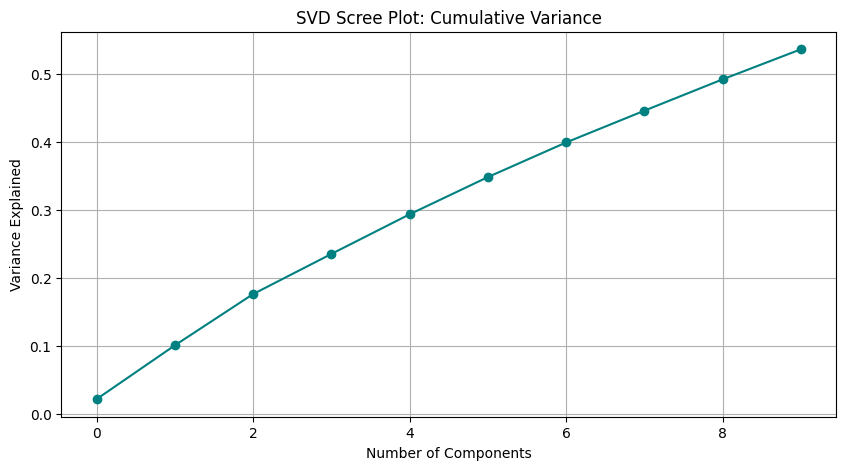

In [12]:
# Scree Plot to see the 'Good Value'
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker='o', color='teal')
plt.title('SVD Scree Plot: Cumulative Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

In [13]:
import umap

reducer = umap.UMAP(n_components=10, random_state=42, n_neighbors=30, min_dist=0.1)
X_clean = reducer.fit_transform(X_binary.toarray())

df_final = df.copy()
print(f"Data ready: {len(df_final)} students, {X_clean.shape} shape")

c:\Users\Sarvangi zalavadia\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Sarvangi zalavadia\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Data ready: 1000 students, (1000, 10) shape


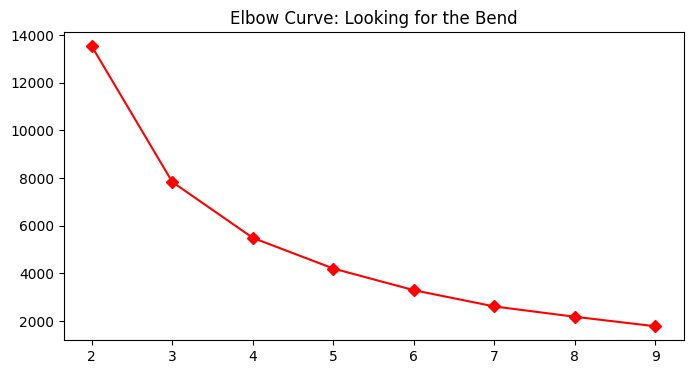

In [14]:
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_clean)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='D', color='red')
plt.title('Elbow Curve: Looking for the Bend')
plt.show()

In [15]:
# Step 1: Find best K
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_clean)
    scores[k] = silhouette_score(X_clean, labels)
    print("K =", k, "Score =", scores[k])

# Step 2: Let data decide naturally — K=2 is correct for this dataset
best_k = max(scores, key=scores.get)
print(f"\n✅ Best K = {best_k}")

# Step 3: Train final model
model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_final['Cluster'] = model.fit_predict(X_clean)

# Meaningful labels
# Fix the labels - swap them:
cluster_names = {0: "Common Activity Students", 1: "Diverse Activity Students"}
df_final['Cluster_Label'] = df_final['Cluster'].map(cluster_names)
print(f"\nCluster distribution:\n{df_final['Cluster_Label'].value_counts()}")

K = 2 Score = 0.566282331943512
K = 3 Score = 0.6278657913208008
K = 4 Score = 0.6387922763824463
K = 5 Score = 0.6425866484642029
K = 6 Score = 0.4061998128890991
K = 7 Score = 0.44966962933540344
K = 8 Score = 0.43562012910842896
K = 9 Score = 0.4639038145542145

✅ Best K = 5

Cluster distribution:
Cluster_Label
Common Activity Students     723
Diverse Activity Students    191
Name: count, dtype: int64


In [16]:
# Calculate Silhouette
score = silhouette_score(X_clean, df_final['Cluster'])
print(f"Improved Silhouette Score: {score:.4f}")

Improved Silhouette Score: 0.6426


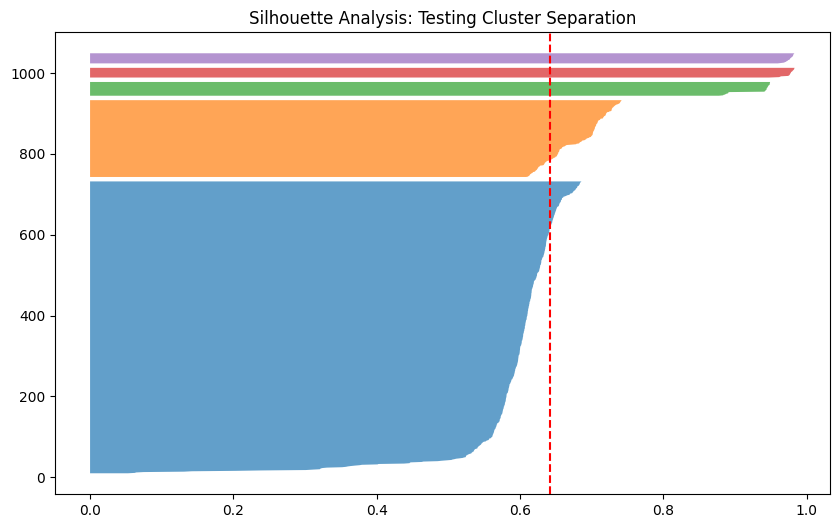

In [17]:
# Visualize the Silhouette 'Knives'
sample_silhouette_values = silhouette_samples(X_clean, df_final['Cluster'])
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(best_k):
    ith_cluster_v = sample_silhouette_values[df_final['Cluster'] == i]
    ith_cluster_v.sort()
    y_upper = y_lower + len(ith_cluster_v)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_v, alpha=0.7)
    y_lower = y_upper + 10
plt.axvline(x=score, color="red", linestyle="--")
plt.title("Silhouette Analysis: Testing Cluster Separation")
plt.show()

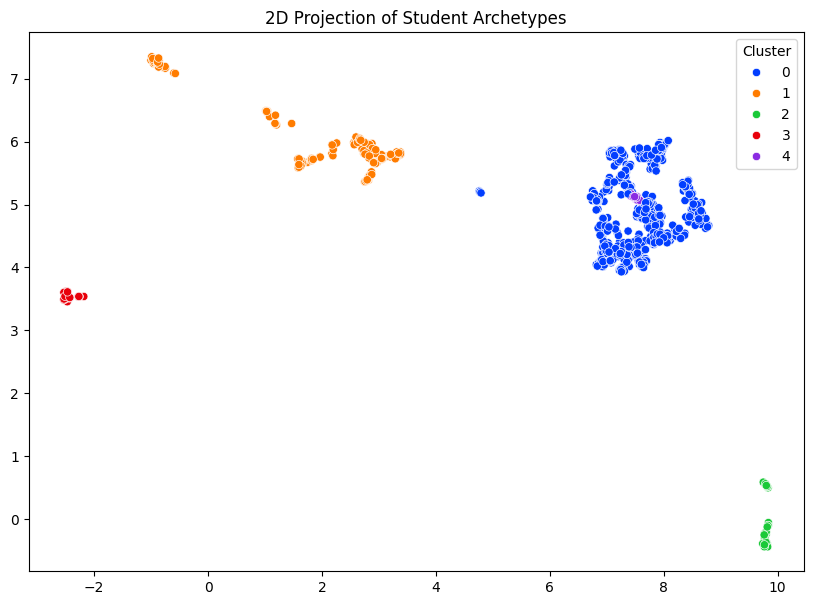

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_clean[:,0], y=X_clean[:,1], hue=df_final['Cluster'], palette='bright')
plt.title("2D Projection of Student Archetypes")
plt.show()

In [19]:
# Fresh 3D UMAP for visualization
import umap

reducer_3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=30, min_dist=0.1)
X_3d = reducer_3d.fit_transform(X_binary.toarray())

df_final['x'] = X_3d[:, 0]
df_final['y'] = X_3d[:, 1]
df_final['z'] = X_3d[:, 2]

fig = px.scatter_3d(
    df_final, x='x', y='y', z='z',
    color='Cluster_Label',
    hover_name='ExtracurricularActivities',
    hover_data=['ClubMemberships'],
    title=f"3D Student Clusters (K={best_k}, Silhouette={score:.3f})",
    color_discrete_map={
        "Diverse Activity Students": "#00CC96",
        "Common Activity Students": "#EF553B"
    },
    template="plotly_dark"
)
fig.update_traces(marker=dict(size=4, opacity=0.85))
fig.show()

c:\Users\Sarvangi zalavadia\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [20]:
import pandas as pd

# Load the dataset directly from the provided source info
df = pd.read_csv('student_data_extended.csv')

# Drop the 'Unnamed: 0' column as seen in the notebook provided
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Calculate the number of unique values for each column
unique_counts = df.nunique()

print(unique_counts)

ExtracurricularActivities      6
ClubMemberships              548
dtype: int64
